## Final Project

### Motivated Questions to solve

**Q: What are the most common mental health challenges (e.g., depression, anxiety) and how do they influence student's gpa, and how do this relationship is moderated by demographic factors (e.g., gender, race/ethnicity)?** As creating a diverse and inclusive academic environment is the goal that most organizations want to, I'm interested in this question to see how academic performance is influenced by those mental health issues. Because students from minority groups or stigmatized groups (eg. Black people) may be influenced by stereotype threat or hostility toward them, the effect of their mental health challenges could be more intense on their academic performance.

### Dataset

The dataset used in this project comes from the Healthy Minds Study (HMS), which provides a comprehensive overview of mental health and related factors among college student populations in the United States. The dataset originally contains 104729 rows and 1554 columns. HMS data is representative of the national student population, as students (observations) are randomly selected from the full list of currently enrolled students at participating institutions. The study includes a wide range of colleges and universities across the country. Participation in HMS is open to all types of higher education institutions, resulting in a large and diverse sample that includes public and private universities, specialty institutions (e.g., colleges of art and design), and institutions of varying academic selectivity (e.g., highly competitive). These institutions are located across all six geographic regions and have student bodies ranging from under 1,000 to over 20,000 students (Healthy Minds Network and American College Health Association, 2023). https://healthymindsnetwork.org/research/data-for-researchers/

In [14]:
import pandas as pd
import numpy as np
import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [2]:
data = pd.read_csv("2324_data.csv")
data.head()

/var/folders/yj/flcty7lx4kv2dv7g_008jwt80000gn/T/ipykernel_7236/3295095435.py:1: DtypeWarning: Columns (12,23,38,44,51,64,109,113,161,170,234,300,348,356,364,370,376,384,392,405,410,523,529,536,540,571,608,641,688,699,712,721,731,790,872,940,970,999,1064,1081,1094,1109,1134,1147,1154,1162,1164,1231,1238,1248,1249,1314,1328,1342,1350,1375,1435,1437,1526,1538) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("2324_data.csv")


,StartDate,RecordedDate,responseid,age,sex_birth,gender_male,gender_female,gender_queer,gender_nonbin,gender_trans,...,inst_size,inst_type,inst_public,inst_geo,inst_specart,inst_speccc,inst_gradrate,inst_msi,peercohort,Random
0,16nov2023 22:51:41,05dec2023 08:17:37,R_006AKYXyGhT9Upb,18.0,1.0,NaN,1.0,NaN,NaN,NaN,...,4,3,1,8,0,0,0.25,0,3.0,0.719747
1,16nov2023 17:12:11,16nov2023 17:37:33,R_006rfKhxwocpzmF,18.0,1.0,NaN,1.0,NaN,NaN,NaN,...,4,3,1,8,0,0,0.25,0,3.0,0.219248
2,24sep2023 18:29:45,24sep2023 18:53:25,R_009nvDs0qZwqoW5,18.0,2.0,1.0,NaN,NaN,NaN,NaN,...,5,3,1,5,0,0,0.50,0,3.0,0.756233
3,30oct2023 08:01:53,21nov2023 07:17:23,R_00R9rAHb09Ydma5,20.0,1.0,NaN,1.0,NaN,NaN,NaN,...,4,3,1,3,0,0,0.24,0,3.0,0.133426
4,24oct2023 09:49:54,21nov2023 07:57:58,R_00SNQFMZ5Kok7Hr,21.0,2.0,1.0,NaN,NaN,NaN,NaN,...,2,4,0,5,0,0,0.57,0,1.0,0.773790


In [3]:
data.shape

(104729, 1554)

Preprocessing the data to make it cleaner to analyze.

In [5]:
data["gender_male"] = data['gender_male'].fillna(0)
data["gender_female"] = data['gender_female'].fillna(0)
data["gender_queer"] = data['gender_queer'].fillna(0)
data["gender_trans"] = data['gender_trans'].fillna(0)
data["race_black"] = data['race_black'].fillna(0)
data["race_ainaan"] = data['race_ainaan'].fillna(0)
data["race_asian"] = data['race_asian'].fillna(0)
data["race_his"] = data['race_his'].fillna(0)
data["race_pi"] = data['race_pi'].fillna(0)
data["race_mides"] = data['race_mides'].fillna(0)
data["race_white"] = data['race_white'].fillna(0)
data["race_other"] = data['race_other'].fillna(0)

In [6]:
data

,StartDate,RecordedDate,responseid,age,sex_birth,gender_male,gender_female,gender_queer,gender_nonbin,gender_trans,...,inst_size,inst_type,inst_public,inst_geo,inst_specart,inst_speccc,inst_gradrate,inst_msi,peercohort,Random
0,16nov2023 22:51:41,05dec2023 08:17:37,R_006AKYXyGhT9Upb,18.0,1.0,0.0,1.0,0.0,NaN,0.0,...,4,3,1,8,0,0,0.25,0,3.0,0.719747
1,16nov2023 17:12:11,16nov2023 17:37:33,R_006rfKhxwocpzmF,18.0,1.0,0.0,1.0,0.0,NaN,0.0,...,4,3,1,8,0,0,0.25,0,3.0,0.219248
2,24sep2023 18:29:45,24sep2023 18:53:25,R_009nvDs0qZwqoW5,18.0,2.0,1.0,0.0,0.0,NaN,0.0,...,5,3,1,5,0,0,0.50,0,3.0,0.756233
3,30oct2023 08:01:53,21nov2023 07:17:23,R_00R9rAHb09Ydma5,20.0,1.0,0.0,1.0,0.0,NaN,0.0,...,4,3,1,3,0,0,0.24,0,3.0,0.133426
4,24oct2023 09:49:54,21nov2023 07:57:58,R_00SNQFMZ5Kok7Hr,21.0,2.0,1.0,0.0,0.0,NaN,0.0,...,2,4,0,5,0,0,0.57,0,1.0,0.773790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104724,06nov2023 08:22:50,06nov2023 08:47:16,R_zffRWaoC4P8OcIp,32.0,1.0,0.0,1.0,0.0,NaN,0.0,...,3,1,1,2,0,1,0.29,0,5.0,0.646475
104725,05nov2023 20:56:06,05nov2023 21:42:50,R_zfmDDqcHWqlBn57,21.0,1.0,0.0,1.0,0.0,NaN,0.0,...,3,4,1,6,0,0,0.24,0,3.0,0.698263
104726,17oct2023 17:51:36,17oct2023 18:11:08,R_zfoCT3DJGcs8FIR,24.0,2.0,1.0,0.0,0.0,NaN,0.0,...,5,3,1,3,0,0,0.77,0,3.0,0.050044
104727,16oct2023 15:47:47,16oct2023 16:17:12,R_zfpIJHce6JkWkZr,23.0,1.0,0.0,1.0,0.0,NaN,0.0,...,4,3,1,3,0,0,0.34,0,3.0,0.577010


In [8]:
conditions = [
    data['gr_A'].notna() & data['gr_B'].isna() & data['gr_C'].isna() & data['gr_D'].isna() & data['gr_F'].isna(),  # Mostly As
    data['gr_B'].notna() & data['gr_A'].notna() & data['gr_C'].isna() & data['gr_D'].isna() & data['gr_F'].isna(), # As and Bs
    data['gr_B'].notna() & data['gr_A'].isna() & data['gr_C'].isna() & data['gr_D'].isna() & data['gr_F'].isna(),  # Mostly Bs
    data['gr_B'].notna() & data['gr_C'].notna() & data['gr_A'].isna() & data['gr_D'].isna() & data['gr_F'].isna(),  # Bs and Cs
    data['gr_C'].notna() & data['gr_A'].isna() & data['gr_B'].isna() & data['gr_D'].isna() & data['gr_F'].isna(),  # Mostly Cs
    data['gr_C'].notna() & data['gr_D'].notna() & data['gr_A'].isna() & data['gr_B'].isna() & data['gr_F'].isna(), # Cs and Ds
    data['gr_D'].notna() & data['gr_A'].isna() & data['gr_B'].isna() & data['gr_C'].isna() & data['gr_F'].isna(),   # Mostly Ds
    data['gr_D'].notna() & data['gr_F'].notna() & data['gr_A'].isna() & data['gr_B'].isna() & data['gr_C'].isna() # Ds and Fs
]

# Corresponding GPA ranges
gpa_ranges = ["3.5-4.0", "3.0-3.49", "2.5-2.99", "2.0-2.49", "1.5-1.99", "1.0-1.49", "0.5-0.99", "0.0-0.49"]

# Apply conditions to create the new column
data['gpa_range'] = np.select(conditions, gpa_ranges, default="Unknown")
data.head()

,StartDate,RecordedDate,responseid,age,sex_birth,gender_male,gender_female,gender_queer,gender_nonbin,gender_trans,...,inst_type,inst_public,inst_geo,inst_specart,inst_speccc,inst_gradrate,inst_msi,peercohort,Random,gpa_range
0,16nov2023 22:51:41,05dec2023 08:17:37,R_006AKYXyGhT9Upb,18.0,1.0,0.0,1.0,0.0,NaN,0.0,...,3,1,8,0,0,0.25,0,3.0,0.719747,3.0-3.49
1,16nov2023 17:12:11,16nov2023 17:37:33,R_006rfKhxwocpzmF,18.0,1.0,0.0,1.0,0.0,NaN,0.0,...,3,1,8,0,0,0.25,0,3.0,0.219248,3.5-4.0
2,24sep2023 18:29:45,24sep2023 18:53:25,R_009nvDs0qZwqoW5,18.0,2.0,1.0,0.0,0.0,NaN,0.0,...,3,1,5,0,0,0.50,0,3.0,0.756233,2.5-2.99
3,30oct2023 08:01:53,21nov2023 07:17:23,R_00R9rAHb09Ydma5,20.0,1.0,0.0,1.0,0.0,NaN,0.0,...,3,1,3,0,0,0.24,0,3.0,0.133426,3.0-3.49
4,24oct2023 09:49:54,21nov2023 07:57:58,R_00SNQFMZ5Kok7Hr,21.0,2.0,1.0,0.0,0.0,NaN,0.0,...,4,0,5,0,0,0.57,0,1.0,0.773790,3.5-4.0


Since the dataset only has categories of each student's gpa (such as mostly As, mostly Bs), I transfer it into a clearer numerical ranges to see how mental health issues influence the gpa range of students. If we need to do correlational analysis, it's possible to find the midpoint of gpa ranges and use it as the continuous data.

### Exploratory data analysis

**Analysis of potential predictors of GPA**

/var/folders/yj/flcty7lx4kv2dv7g_008jwt80000gn/T/ipykernel_7236/445560232.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gpa_range', y='deprawsc', data=data, palette='coolwarm')


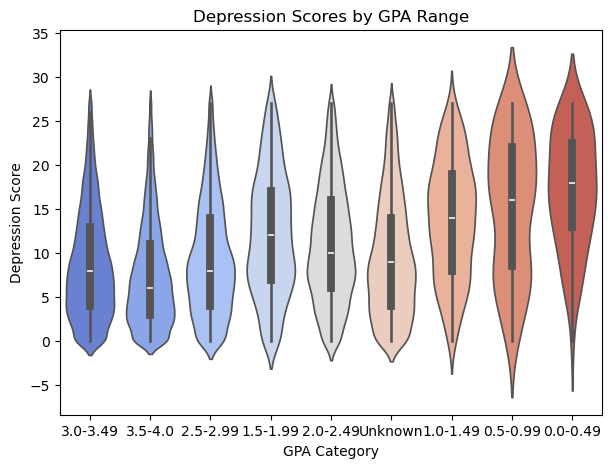

In [18]:
plt.figure(figsize=(7, 5))
sns.violinplot(x='gpa_range', y='deprawsc', data=data, palette='coolwarm')
plt.title('Depression Scores by GPA Range')
plt.xlabel('GPA Category')
plt.ylabel('Depression Score')
plt.show()

/var/folders/yj/flcty7lx4kv2dv7g_008jwt80000gn/T/ipykernel_7236/1403187720.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gpa_range', y='anx_score', data = data, palette='coolwarm')


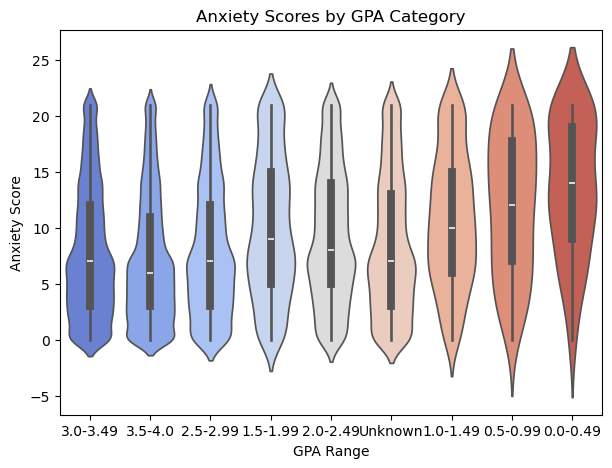

In [19]:
plt.figure(figsize=(7, 5))
sns.violinplot(x='gpa_range', y='anx_score', data = data, palette='coolwarm')
plt.title('Anxiety Scores by GPA Category')
plt.xlabel('GPA Range')
plt.ylabel('Anxiety Score')
plt.show()

/var/folders/yj/flcty7lx4kv2dv7g_008jwt80000gn/T/ipykernel_7236/845556430.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gpa_range', y='lonesc', data = data, palette='coolwarm')


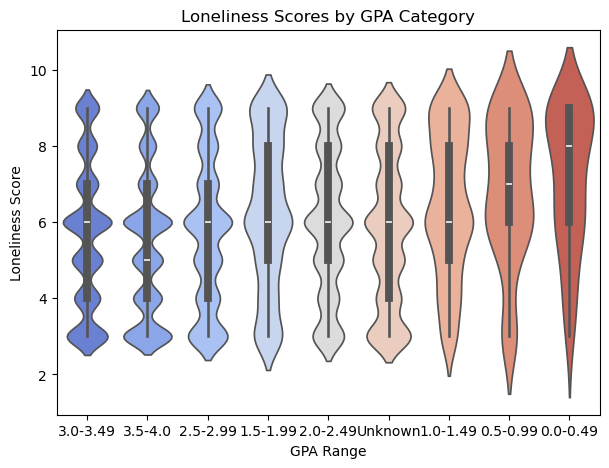

In [21]:
plt.figure(figsize=(7, 5))
sns.violinplot(x='gpa_range', y='lonesc', data = data, palette='coolwarm')
plt.title('Loneliness Scores by GPA Category')
plt.xlabel('GPA Range')
plt.ylabel('Loneliness Score')
plt.show()

/var/folders/yj/flcty7lx4kv2dv7g_008jwt80000gn/T/ipykernel_7236/587396206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gpa_range', y='deprawsc', data=data, palette='coolwarm', ax=axes[0])
/var/folders/yj/flcty7lx4kv2dv7g_008jwt80000gn/T/ipykernel_7236/587396206.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gpa_range', y='anx_score', data=data, palette='coolwarm', ax=axes[1])
/var/folders/yj/flcty7lx4kv2dv7g_008jwt80000gn/T/ipykernel_7236/587396206.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gpa_range',

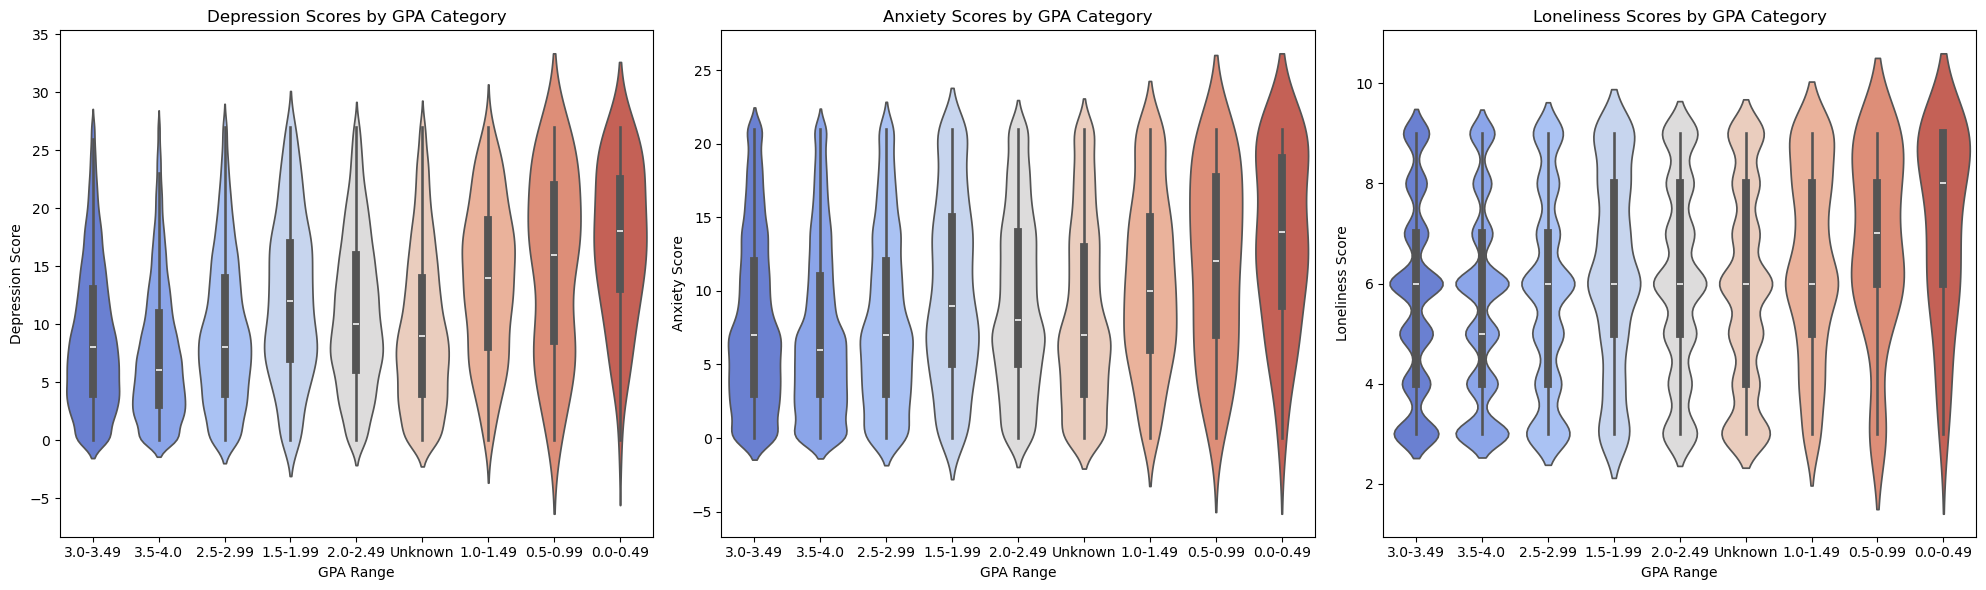

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.violinplot(x='gpa_range', y='deprawsc', data=data, palette='coolwarm', ax=axes[0])
axes[0].set_title('Depression Scores by GPA Category')
axes[0].set_xlabel('GPA Range')
axes[0].set_ylabel('Depression Score')

# Anxiety score
sns.violinplot(x='gpa_range', y='anx_score', data=data, palette='coolwarm', ax=axes[1])
axes[1].set_title('Anxiety Scores by GPA Category')
axes[1].set_xlabel('GPA Range')
axes[1].set_ylabel('Anxiety Score')

# Loneliness score
sns.violinplot(x='gpa_range', y='lonesc', data=data, palette='coolwarm', ax=axes[2])
axes[2].set_title('Loneliness Scores by GPA Category')
axes[2].set_xlabel('GPA Range')
axes[2].set_ylabel('Loneliness Score')

# Adjust layout
plt.tight_layout()
plt.show()

From these violin plots, we could see how the distribution density of depression score, anxiety score, and loneliness score change with the GPA range those students have. So I tend to use these variables to predict the academic performance.

**Analysis of potential moderators of the relationship between mental issues and GPA**

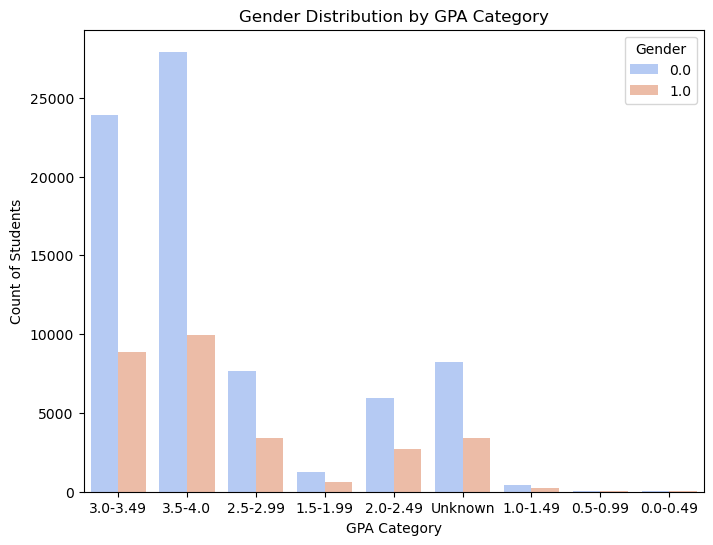

In [26]:
plt.figure(figsize=(8, 6))
sns.countplot(x='gpa_range', hue='gender_male', data=data, palette='coolwarm')
plt.title('Gender Distribution by GPA Category')
plt.xlabel('GPA Category')
plt.ylabel('Count of Students')
plt.legend(title='Gender')
plt.show()

We could see the counts of students in each gpa category are different from gender, but it may be caused by the sample bias.

In [27]:
data["sex_birth"].value_counts()

sex_birth
1.0    75087
2.0    29438
3.0       65
Name: count, dtype: int64

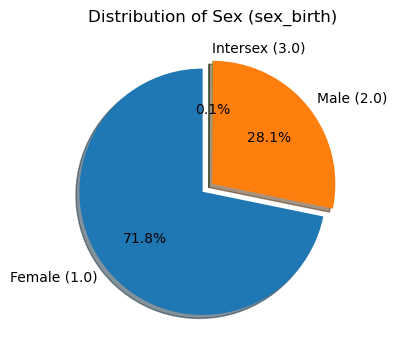

In [30]:
labels = ['Female (1.0)', 'Male (2.0)', 'Intersex (3.0)']
sizes = [75087, 29438, 65]  # Values from your data
explode = (0.1, 0, 0)  # Ensure the length matches sizes

# Create the pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%',  # Display percentages
    startangle=90,      # Rotate to start from the top
    explode=explode,    # Separate the female slice slightly
    shadow=True         # Add a shadow for better aesthetics
)
plt.title('Distribution of Sex (sex_birth)')
plt.show()

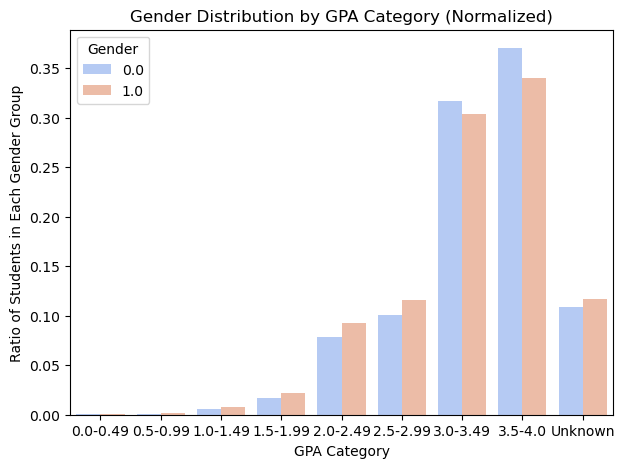

In [31]:
gender_counts = data['gender_male'].value_counts()
gpa_gender_counts = data.groupby(['gpa_range', 'gender_male']).size().reset_index(name='count')
gpa_gender_counts['ratio'] = gpa_gender_counts.apply(lambda row: row['count'] / gender_counts[row['gender_male']], axis=1)

plt.figure(figsize=(7, 5))
sns.barplot(x='gpa_range', y='ratio', hue='gender_male', data=gpa_gender_counts, palette='coolwarm')

# Labels and title
plt.title('Gender Distribution by GPA Category (Normalized)')
plt.xlabel('GPA Category')
plt.ylabel('Ratio of Students in Each Gender Group')
plt.legend(title='Gender')

# Show the plot
plt.show()

Using the ratio of students in each gender group, we can still see small difference in GPA categories, showing that gender difference may be a potential moderator for relationship to academic performance.

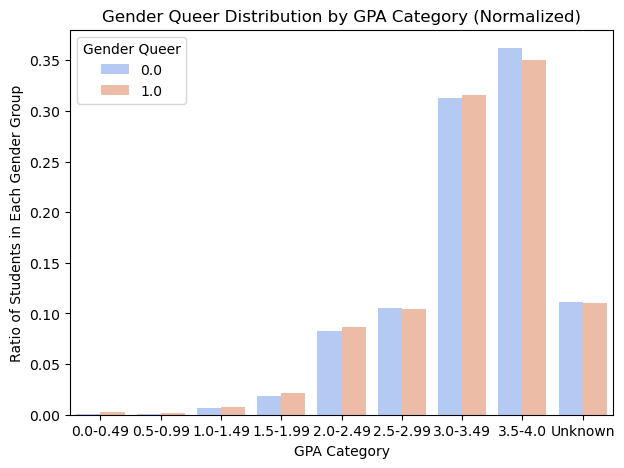

In [35]:
queer_counts = data['gender_queer'].value_counts()
gpa_queer_counts = data.groupby(['gpa_range', 'gender_queer']).size().reset_index(name='count')
gpa_queer_counts['ratio'] = gpa_queer_counts.apply(lambda row: row['count'] / queer_counts[row['gender_queer']], axis=1)

plt.figure(figsize=(7, 5))
sns.barplot(x='gpa_range', y='ratio', hue='gender_queer', data=gpa_queer_counts, palette='coolwarm')

# Labels and title
plt.title('Gender Queer Distribution by GPA Category (Normalized)')
plt.xlabel('GPA Category')
plt.ylabel('Ratio of Students in Each Gender Group')
plt.legend(title='Gender Queer')

# Show the plot
plt.show()

It seems that from the gender queer groups, the ratios in each gpa category only have small differences. Gender queer is not an influential predictor in this dataset.

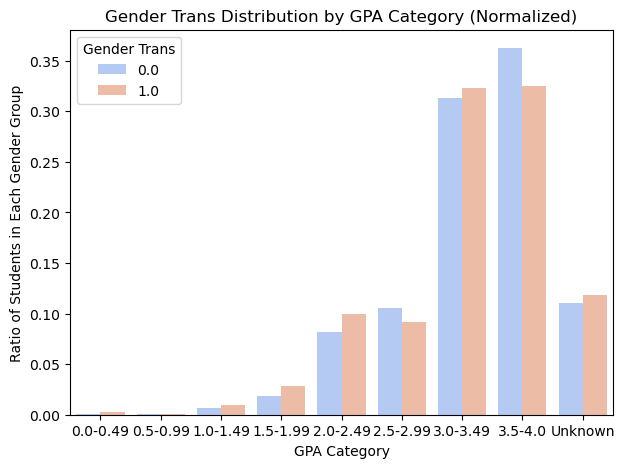

In [37]:
trans_counts = data['gender_trans'].value_counts()
gpa_trans_counts = data.groupby(['gpa_range', 'gender_trans']).size().reset_index(name='count')
gpa_trans_counts['ratio'] = gpa_trans_counts.apply(lambda row: row['count'] / trans_counts[row['gender_trans']], axis=1)

plt.figure(figsize=(7, 5))
sns.barplot(x='gpa_range', y='ratio', hue='gender_trans', data=gpa_trans_counts, palette='coolwarm')

# Labels and title
plt.title('Gender Trans Distribution by GPA Category (Normalized)')
plt.xlabel('GPA Category')
plt.ylabel('Ratio of Students in Each Gender Group')
plt.legend(title='Gender Trans')

# Show the plot
plt.show()

We can see that there's difference between ratios of transgender students and cisgender students in gpa category. It indicates that gender_trans could be a potential predictor or moderator for academic performance.

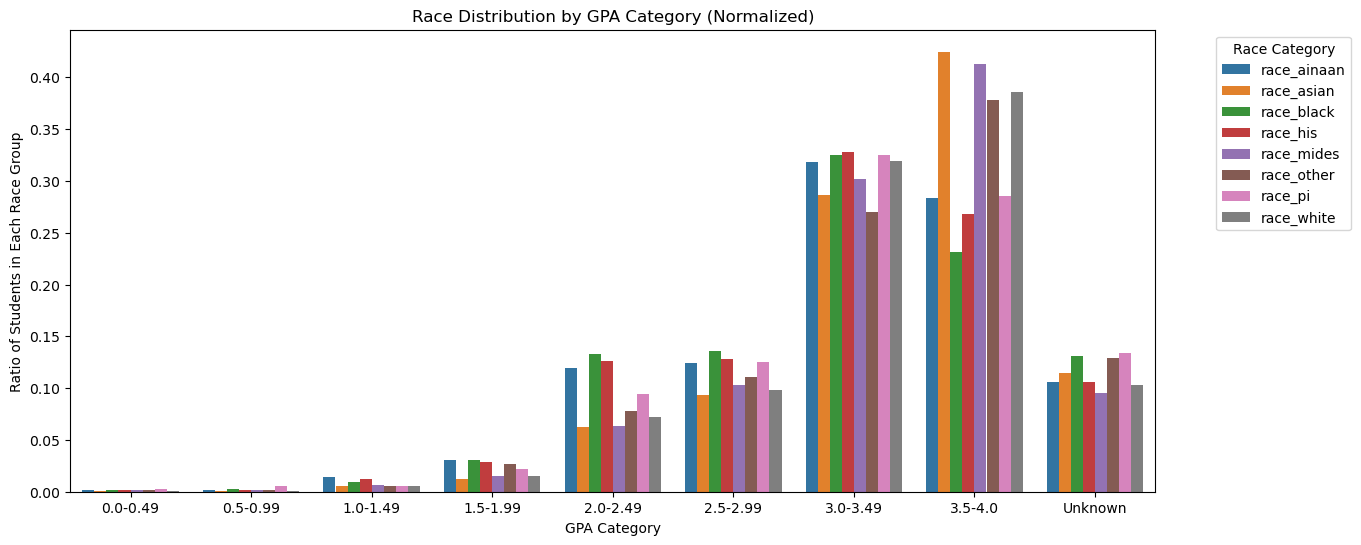

In [39]:
race_categories = ['race_black', 'race_ainaan', 'race_asian', 'race_his', 'race_pi', 'race_mides', 'race_white', 'race_other']
race_totals = {race: data[race].sum() for race in race_categories}
gpa_race_counts = data.melt(id_vars=['gpa_range'], value_vars=race_categories, 
                            var_name='race_category', value_name='is_race')
gpa_race_counts = gpa_race_counts[gpa_race_counts['is_race'] == 1]
gpa_race_counts = gpa_race_counts.groupby(['gpa_range', 'race_category']).size().reset_index(name='count')
gpa_race_counts['ratio'] = gpa_race_counts.apply(
    lambda row: row['count'] / race_totals[row['race_category']], axis=1
)

plt.figure(figsize=(14, 6))
sns.barplot(x='gpa_range', y='ratio', hue='race_category', data=gpa_race_counts, palette='tab10')

plt.title('Race Distribution by GPA Category (Normalized)')
plt.xlabel('GPA Category')
plt.ylabel('Ratio of Students in Each Race Group')
plt.legend(title='Race Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

We can see a significant difference in the distribution of rations of students in each race group with the GPA category where some racial groups are overrepresented and some are underrepresented in a GPA category. For instance, in the GPA range of 3.5-4.0, the ratios of asian and Middle Eastern students are extremely high, whereas the ratio for black students is extremely low. Thus, I would select race as a moderator to see how it potentially affects the relationship between mental health and academic performance.

/var/folders/yj/flcty7lx4kv2dv7g_008jwt80000gn/T/ipykernel_7236/272927351.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gpa_range', y='fincur', data = data, palette='coolwarm')


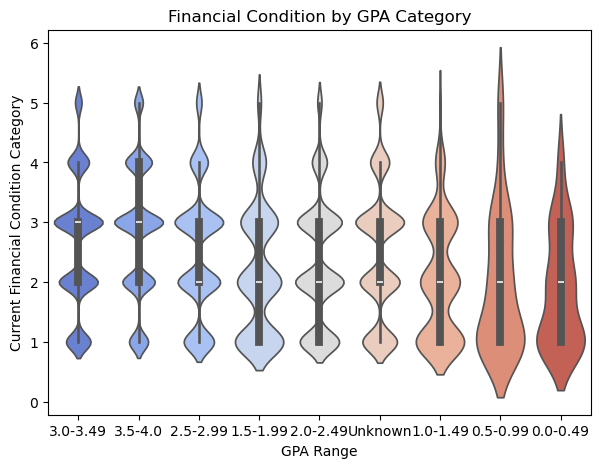

In [44]:
plt.figure(figsize=(7, 5))
sns.violinplot(x='gpa_range', y='fincur', data = data, palette='coolwarm')
plt.title('Financial Condition by GPA Category')
plt.xlabel('GPA Range')
plt.ylabel('Current Financial Condition Category')
plt.show()

/var/folders/yj/flcty7lx4kv2dv7g_008jwt80000gn/T/ipykernel_7236/4281393751.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='gpa_range', y='finpast', data = data, palette='coolwarm')


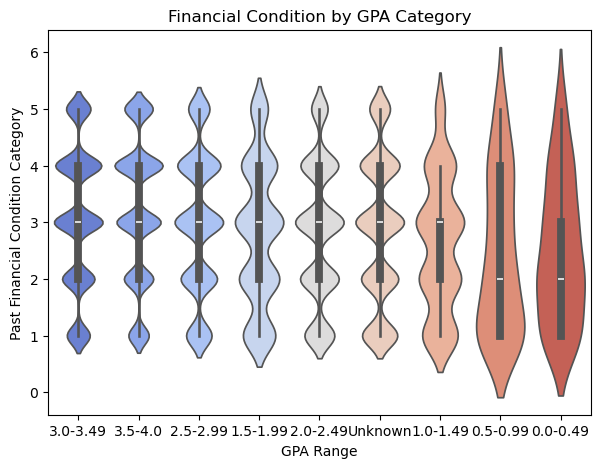

In [43]:
plt.figure(figsize=(7, 5))
sns.violinplot(x='gpa_range', y='finpast', data = data, palette='coolwarm')
plt.title('Financial Condition by GPA Category')
plt.xlabel('GPA Range')
plt.ylabel('Past Financial Condition Category')
plt.show()

It's obvious that financial condition of students with poorer background as a distribution of GPA range more with low gpa values. It clearly indicates how socioeconomic status could influence a student's academic performance.

In [45]:
filtered = pd.DataFrame(data[['gr_A','gr_B','gr_C','gr_D','gr_F','gr_none','gr_dk', 'gpa_range',
                            'gad7_1','gad7_2','gad7_3','gad7_4','gad7_5','gad7_6','gad7_7','anx_score',
                            'phq9_1','phq9_2','phq9_3','phq9_4','phq9_5','phq9_6','phq9_7','phq9_8','phq9_9', 'deprawsc',
                            'lonesc', 'lonely', "gender_male", 'gender_trans',
                            'race_black', 'race_ainaan', 'race_asian', 'race_his', 'race_pi', 'race_mides', 'race_white', 'race_other',
                            'fincur', 'finpast',
                            ]],
                       columns=['gr_A','gr_B','gr_C','gr_D','gr_F','gr_none','gr_dk', 'gpa_range',
                            'gad7_1','gad7_2','gad7_3','gad7_4','gad7_5','gad7_6','gad7_7','anx_score',
                            'phq9_1','phq9_2','phq9_3','phq9_4','phq9_5','phq9_6','phq9_7','phq9_8','phq9_9', 'deprawsc',
                            'lonesc', 'lonely', "gender_male", 'gender_trans',
                            'race_black', 'race_ainaan', 'race_asian', 'race_his', 'race_pi', 'race_mides', 'race_white', 'race_other',
                            'fincur', 'finpast',])
filtered.head()

,gr_A,gr_B,gr_C,gr_D,gr_F,gr_none,gr_dk,gpa_range,gad7_1,gad7_2,...,race_black,race_ainaan,race_asian,race_his,race_pi,race_mides,race_white,race_other,fincur,finpast
0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,3.0-3.49,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,3.0
1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,3.0
2,NaN,1.0,NaN,NaN,NaN,NaN,NaN,2.5-2.99,2.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,5.0
3,1.0,1.0,NaN,NaN,NaN,NaN,NaN,3.0-3.49,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,3.0
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,5.0


I pick the variables that I believe would be related to the gpa range. The mental health predictors include: anxiety score(anx_score), deprawsc(depression score), loneliness score(lonesc). The moderators I choose to see how they impact the relationship between mental health scores and gpa are gender, gender identity (gender_trans), race (eg. race_black, race_asian, race_his), and socioeconomic status of financial condition (fincur, finpast). These would all be potentially influential to one's mental state and hence affect the effectiveness or creativity in academic settings.

In [51]:
filtered['gender_trans'].notna

<bound method Series.notna of 0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
104724    0.0
104725    0.0
104726    0.0
104727    0.0
104728    0.0
Name: gender_trans, Length: 104729, dtype: float64>

### Deal with missing values in the dataset

Drop the observations with gpa not included in at least one category.

In [52]:
filtered1 = filtered.dropna(how='all', subset=['gr_A','gr_B','gr_C','gr_D','gr_F','gr_none','gr_dk'])
filtered1

,gr_A,gr_B,gr_C,gr_D,gr_F,gr_none,gr_dk,gpa_range,gad7_1,gad7_2,...,race_black,race_ainaan,race_asian,race_his,race_pi,race_mides,race_white,race_other,fincur,finpast
0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,3.0-3.49,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,3.0
1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,3.0
2,NaN,1.0,NaN,NaN,NaN,NaN,NaN,2.5-2.99,2.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,5.0
3,1.0,1.0,NaN,NaN,NaN,NaN,NaN,3.0-3.49,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,3.0
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104724,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0
104725,NaN,1.0,NaN,NaN,NaN,NaN,NaN,2.5-2.99,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
104726,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,4.0,3.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0
104727,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,5.0


Drop the observations without the data of predictors we chose.

In [119]:
filtered1 = filtered1.dropna(subset=['anx_score', 'deprawsc', 'lonesc', 'lonely', 'fincur', 'finpast'])
filtered1

,gr_A,gr_B,gr_C,gr_D,gr_F,gr_none,gr_dk,gpa_range,gad7_1,gad7_2,...,race_ainaan,race_asian,race_his,race_pi,race_mides,race_white,race_other,fincur,finpast,gpa_numeric
0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,3.0-3.49,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,3.0,3.25
1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,3.0,3.75
2,NaN,1.0,NaN,NaN,NaN,NaN,NaN,2.5-2.99,2.0,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,5.0,2.75
3,1.0,1.0,NaN,NaN,NaN,NaN,NaN,3.0-3.49,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,3.0,3.25
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,3.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,5.0,3.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104724,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,3.75
104725,NaN,1.0,NaN,NaN,NaN,NaN,NaN,2.5-2.99,4.0,4.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,2.75
104726,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,4.0,3.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,4.0,3.75
104727,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,5.0,3.75


Being not null in gr_dk and gr_none means that the GPA of this student doesn't fit in all the gpa categories or don't know this information. Drop those observations.

In [204]:
filtered1.head()

,gr_A,gr_B,gr_C,gr_D,gr_F,gr_none,gr_dk,gpa_range,gad7_1,gad7_2,...,race_asian,race_his,race_pi,race_mides,race_white,race_other,fincur,finpast,gpa_numeric,gpa_range_ordinal
0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,3.0-3.49,3.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,2.0,3.0,3.25,7
1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,3.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,4.0,3.0,3.75,8
2,NaN,1.0,NaN,NaN,NaN,NaN,NaN,2.5-2.99,2.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,4.0,5.0,2.75,6
3,1.0,1.0,NaN,NaN,NaN,NaN,NaN,3.0-3.49,3.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,3.0,3.0,3.25,7
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,3.5-4.0,3.0,2.0,...,0.0,0.0,0.0,0.0,1.0,0.0,4.0,5.0,3.75,8


**This is the final dataset we would use to analyze and find relationships between mental health problems and academic performance.**